# NIFTY-Sentinel: supervised stress models
This notebook uses chronological splits only. It compares an interpretable logistic baseline with nonlinear models and exports dashboard-ready predictions.

In [1]:
import os
os.chdir(r'C:\Users\deepa\Documents\ChatGPT\ML 2 porject')
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from src.config import FIGURES_DIR, MODELS_DIR, PROCESSED_DATA_DIR

state = pd.read_csv(PROCESSED_DATA_DIR / 'regime_features.csv', parse_dates=['date']).set_index('date')
connected = pd.read_csv(PROCESSED_DATA_DIR / 'connectedness_features.csv', parse_dates=['date']).set_index('date')
dataset = state.join(connected, how='left')
TARGET = 'stress_next_10d'
feature_columns = [c for c in dataset.select_dtypes('number').columns if c not in {TARGET, 'nifty_close'}]
labeled = dataset.dropna(subset=[TARGET]).copy()
X, y = labeled[feature_columns], labeled[TARGET].astype(int)
print('Observations:', len(X), 'Stress prevalence:', y.mean().round(3))

Observations: 4095 Stress prevalence: 0.169


In [2]:
models = {
    'logistic': Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', StandardScaler()), ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]),
    'random_forest': Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', RandomForestClassifier(n_estimators=500, min_samples_leaf=10, class_weight='balanced_subsample', random_state=42, n_jobs=-1))]),
}

rows = []
splits = TimeSeriesSplit(n_splits=5)
for name, model in models.items():
    for fold, (train_idx, test_idx) in enumerate(splits.split(X), start=1):
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        probability = model.predict_proba(X.iloc[test_idx])[:, 1]
        rows.append({'model': name, 'fold': fold, 'roc_auc': roc_auc_score(y.iloc[test_idx], probability), 'pr_auc': average_precision_score(y.iloc[test_idx], probability)})
results = pd.DataFrame(rows)
results.to_csv(PROCESSED_DATA_DIR / 'walk_forward_metrics.csv', index=False)
results.groupby('model')[['roc_auc', 'pr_auc']].agg(['mean', 'std']).round(3)

roc_auc        pr_auc       
                 mean    std   mean    std
model                                     
logistic        0.740  0.077  0.400  0.141
random_forest   0.734  0.065  0.422  0.130

In [3]:
best_name = results.groupby('model')['pr_auc'].mean().idxmax()
best_model = models[best_name].fit(X, y)
joblib.dump({'model': best_model, 'features': feature_columns, 'target': TARGET}, MODELS_DIR / 'stress_model.joblib')

latest_features = dataset[feature_columns]
dataset['stress_probability'] = best_model.predict_proba(latest_features)[:, 1]
dataset['warning_level'] = pd.cut(dataset['stress_probability'], bins=[-0.01, 0.30, 0.60, 1.0], labels=['Normal', 'Elevated', 'Severe'])
dataset[['stress_probability', 'warning_level']].tail()

,stress_probability,warning_level
date,,
2026-09-11,0.181561,Normal
2026-09-15,0.194171,Normal
2026-09-16,0.135646,Normal
2026-09-17,0.104553,Normal
2026-09-18,0.121049,Normal


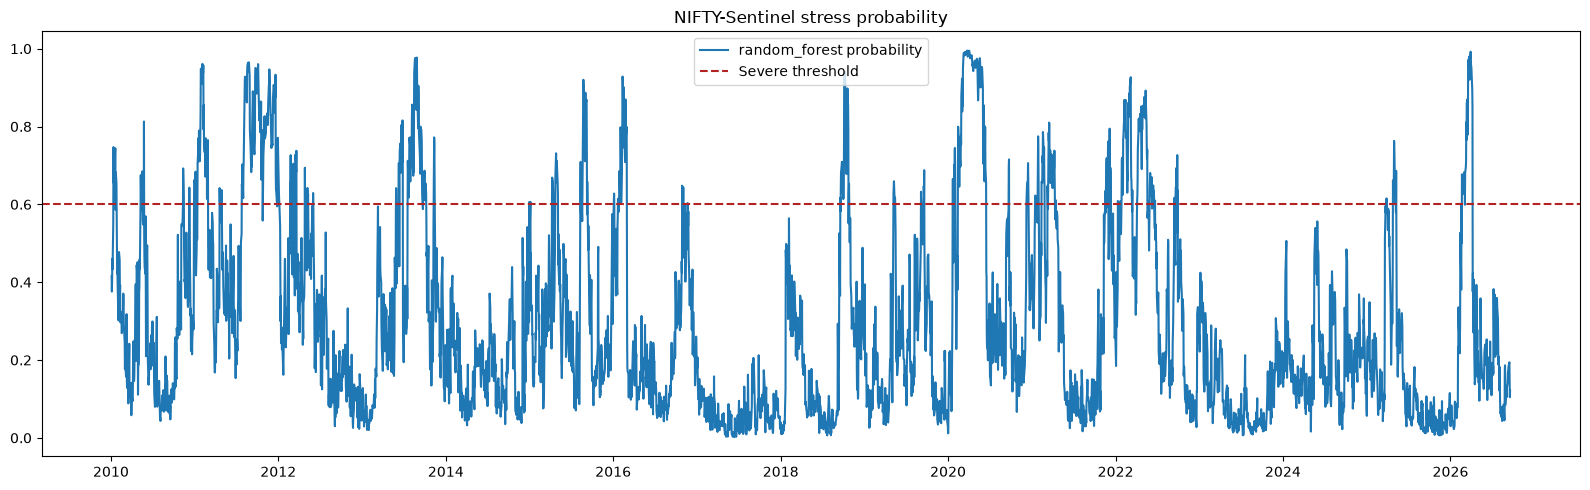

In [4]:
dashboard = dataset.reset_index().rename(columns={'index': 'date'})
dashboard[['date', 'nifty_close', 'regime', 'stress_probability', 'warning_level']].to_csv(PROCESSED_DATA_DIR / 'dashboard_data.csv', index=False)

plt.figure(figsize=(16, 5))
plt.plot(dashboard['date'], dashboard['stress_probability'], label=f'{best_name} probability')
plt.axhline(0.60, color='firebrick', linestyle='--', label='Severe threshold')
plt.legend()
plt.title('NIFTY-Sentinel stress probability')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'stress_probability_timeline.png', dpi=180, bbox_inches='tight')
plt.show()

## Interpretation note
The dashboard prediction is decision-support output. Do not describe it as a crash forecast, trading signal, or causal conclusion. Add SHAP explanations and ablation experiments before making final performance claims.